# QC CODE REPORT GENERATOR

---

##0.REFERENCE

##1.CONTEXT

###1.1.OVERVIEW

**QuantConnect Code Reviewer Agent — Notebook Introduction**

*A six-stage agentic pipeline that audits QuantConnect algorithms for correctness, platform fidelity, and deployment readiness*

---

**What This Notebook Does**

Writing a QuantConnect algorithm that compiles is easy. Writing one that behaves correctly under all runtime conditions — that handles warm-up properly, guards against stale state, avoids oscillatory liquidation, and produces the same results in live trading as it does in backtesting — is considerably harder. The failure modes are subtle, numerous, and often invisible until real capital is at risk. A strategy can pass a backtest with excellent metrics and still contain silent bugs that only surface when market conditions shift, data gaps appear, or universe membership changes mid-session.

This notebook implements a **QuantConnect Code Reviewer Agent**: a six-stage agentic pipeline, powered by Claude, that takes a submitted QuantConnect algorithm and subjects it to a structured, multi-dimensional audit. The agent does not merely scan for syntax errors. It reasons about the algorithm's operational semantics, checks its behavior against documented QuantConnect and LEAN conventions, classifies every problem it finds by severity, generates corrected code for each critical and major finding, and produces a practical test plan for validating the fixes. The pipeline is designed to catch the class of errors that are hardest to find through manual reading: the ones that are syntactically valid, logically plausible on first reading, but behaviorally wrong in the specific context of the LEAN event-driven runtime.

---

**Why a Multi-Stage Pipeline**

The same architectural rationale that motivates the previous notebooks in this series applies here, but with an important difference in emphasis. The migration agent and the code generation agent both move from intent to implementation — they start with something incomplete and produce something finished. The reviewer agent moves in the opposite direction: it starts with something that appears finished and works backwards to discover what is wrong with it.

This reversal changes what each stage must do. A generation pipeline needs to decompose intent and synthesize structure. A review pipeline needs to parse structure and infer intent — then check whether the stated intent and the actual behavior match. These are different cognitive operations, and they benefit from the same stage-wise separation. If a single Claude call were asked to ingest the code, parse its structure, audit five dimensions, classify severities, generate fixes, and produce a test plan simultaneously, the result would be superficial on every dimension. By distributing the work across six focused calls, each stage can go deep on its specific responsibility and pass a richer, more structured artifact to the next stage.

The pipeline is also designed to be honest about incompleteness. Real QuantConnect algorithms submitted for review are rarely fully formed. They may be missing risk controls, have placeholder logic in some methods, or be partially refactored. The ingestion stage classifies what is present and what is absent before any audit begins, so the downstream stages can calibrate their expectations rather than generating false positives against methods that the user has not yet written.

---

**Stage 1 — Submission Ingestion**

The pipeline begins with a classification pass, not an audit. Stage 1 asks three questions about the submitted code: what is its architecture (monolithic `QCAlgorithm`, Algorithm Framework, or a mixed or unclear combination), what language is it written in, and what does it appear to be trying to do? The answers to these questions determine how every subsequent stage reasons about the code.

The architecture classification matters because the review criteria differ between architectural styles. A monolithic algorithm concentrates signal, sizing, and execution logic in a single class; the reviewer checks that this concentration is internally consistent. An Algorithm Framework implementation distributes logic across Universe, Alpha, Portfolio Construction, Execution, and Risk Management models; the reviewer checks that each model respects its boundaries and does not carry state or responsibilities that belong to a different layer. Getting this classification right before the audit begins prevents the agent from applying the wrong checklist to the wrong code structure.

Stage 1 also catalogues every structural element it can find — class name, lifecycle methods, subscriptions, indicators, scheduled events, custom methods — and flags anything that appears to be missing. This inventory becomes the reference against which the structural parse in Stage 2 is conducted.

---

**Stage 2 — Structural Parse**

Stage 2 moves from classification to inspection. It checks the three structural pillars of a LEAN algorithm: the `Initialize` method, the event handler set, and the subscription integrity.

The `Initialize` inspection checks that configuration is declared in the correct order — dates and cash before subscriptions, subscriptions before indicators, indicators before scheduled events — because LEAN's runtime depends on this ordering and does not always fail loudly when it is violated. The event handler inspection checks that every handler present has the correct method signature for the target platform version, and flags any expected handlers that are entirely absent. The subscription integrity check verifies that every symbol referenced in trading logic, indicator registration, or scheduled events is actually subscribed, and that consolidators or custom data feeds are properly declared.

The output of Stage 2 is a structured parse report that assigns each item a status of OK, WARNING, or MISSING. This report is consumed by Stage 3, where it provides the structural map that anchors the five-dimension audit.

---

**Stage 3 — Five-Dimension Audit**

Stage 3 is the analytical core of the pipeline. It applies five independent audit lenses to the code, each targeting a distinct class of failure.

The first dimension, **lifecycle**, checks that the initialization sequence is dependency-safe and that event handlers are named and scoped correctly. The second dimension, **data and readiness**, checks that the `IsWarmingUp` guard is present and correctly positioned, that indicator `IsReady` properties are checked before values are read, that resolutions are consistent between subscriptions and indicator registrations, and that the code handles sparse or missing data bars without crashing or silently using stale values.

The third dimension, **state logic**, checks for the class of errors that are hardest to find in manual review: regime flags that are set but never reset, `RollingWindow` indexing mistakes, state variables that persist across liquidation events when they should be cleared, and cross-bar assumptions that break during data gaps or market holidays. The fourth dimension, **execution**, checks for repeated order submissions without an invested or pending-order guard, missing open order inspections, oscillatory liquidation risk where an exit signal is immediately followed by a re-entry, and confusion between target-based and ticket-based execution semantics.

The fifth dimension, **architecture**, checks for the structural failures that specifically afflict Algorithm Framework implementations: monolithic logic leaking into modular models, state held in the wrong layer of the decomposition, and universe selection producing side effects outside the designated `OnSecuritiesChanged` boundary. Each finding is tagged with its dimension and location, producing a structured list that feeds directly into the severity classification.

---

**Stage 4 — Severity Classification**

Stage 4 converts the raw audit findings into a structured severity table and a four-way verdict. Every finding is classified as Critical, Major, or Minor, using definitions that map directly to the operational consequences of leaving the problem unfixed.

A Critical finding prevents the algorithm from running or causes an immediate runtime exception. A Major finding allows the algorithm to run but produces silently incorrect behavior — wrong signals, missed trades, inflated backtest returns, or look-ahead bias. A Minor finding does not affect correctness but introduces fragility, violates platform idioms, or makes the code harder to maintain and adapt. The verdict — Pass, Pass with Warnings, Fail and Revise, or Incomplete — is determined mechanically from the highest severity level present. This verdict is the clearest single answer to the question the user is implicitly asking when they submit code for review: is this algorithm ready to run?

---

**Stage 5 — Remediation Synthesis**

For every Critical and Major finding, Stage 5 generates a corrected code snippet accompanied by a one-sentence LEAN platform rationale. The rationale is not a generic explanation of why the pattern is bad practice; it is a specific statement of the LEAN-documented reason why the original code would misbehave in the runtime and why the fix resolves it. After all individual fixes are presented, Stage 5 assembles the complete corrected algorithm — a single, copy-paste-ready Python file that incorporates every fix and is ready to be dropped into the QuantConnect cloud IDE or a local LEAN environment.

The re-audit loop shown in the pipeline diagram is implicit here: the remediation stage reads both the audit findings and the original code simultaneously, which means it can check that each proposed fix does not introduce a new problem while solving the original one.

---

**Stage 6 — Validation Checklist**

The pipeline closes not with code but with a test plan. Stage 6 produces four categories of validation guidance: backtest checks (specific things to look for in the equity curve and log output), paper trading checks (order flow and position transitions to monitor in a live paper session), edge case tests (specific scenarios to stress-test manually, such as gap openings, halted securities, and universe membership changes mid-session), and deployment warnings (remaining differences between backtesting and live behavior that the user should account for before going live).

This checklist matters because code correctness and behavioral correctness are not the same thing. A fix that removes a duplicate order submission guard is syntactically correct and LEAN-compliant, but whether it actually produces the intended trading behavior under all market conditions is a question that only a controlled test can answer. Stage 6 gives the user a structured path from receiving the corrected code to gaining confidence that the corrections worked.

---

**How to Use This Notebook**

Replace the `ALGORITHM_TO_REVIEW` variable in Cell 5 with your own QuantConnect algorithm. Optionally populate `REVIEW_CONTEXT` with a plain-language description of what the strategy is supposed to do — the agent uses this to distinguish intentional design choices from bugs. Run all cells in sequence. The final cell prints the severity verdict, the full corrected algorithm, and the validation checklist. Each intermediate stage also prints its output as it runs, so you can follow the agent's reasoning step by step and intervene at any point if the classification or audit requires clarification.

###1.2.FLOW DIAGRAM

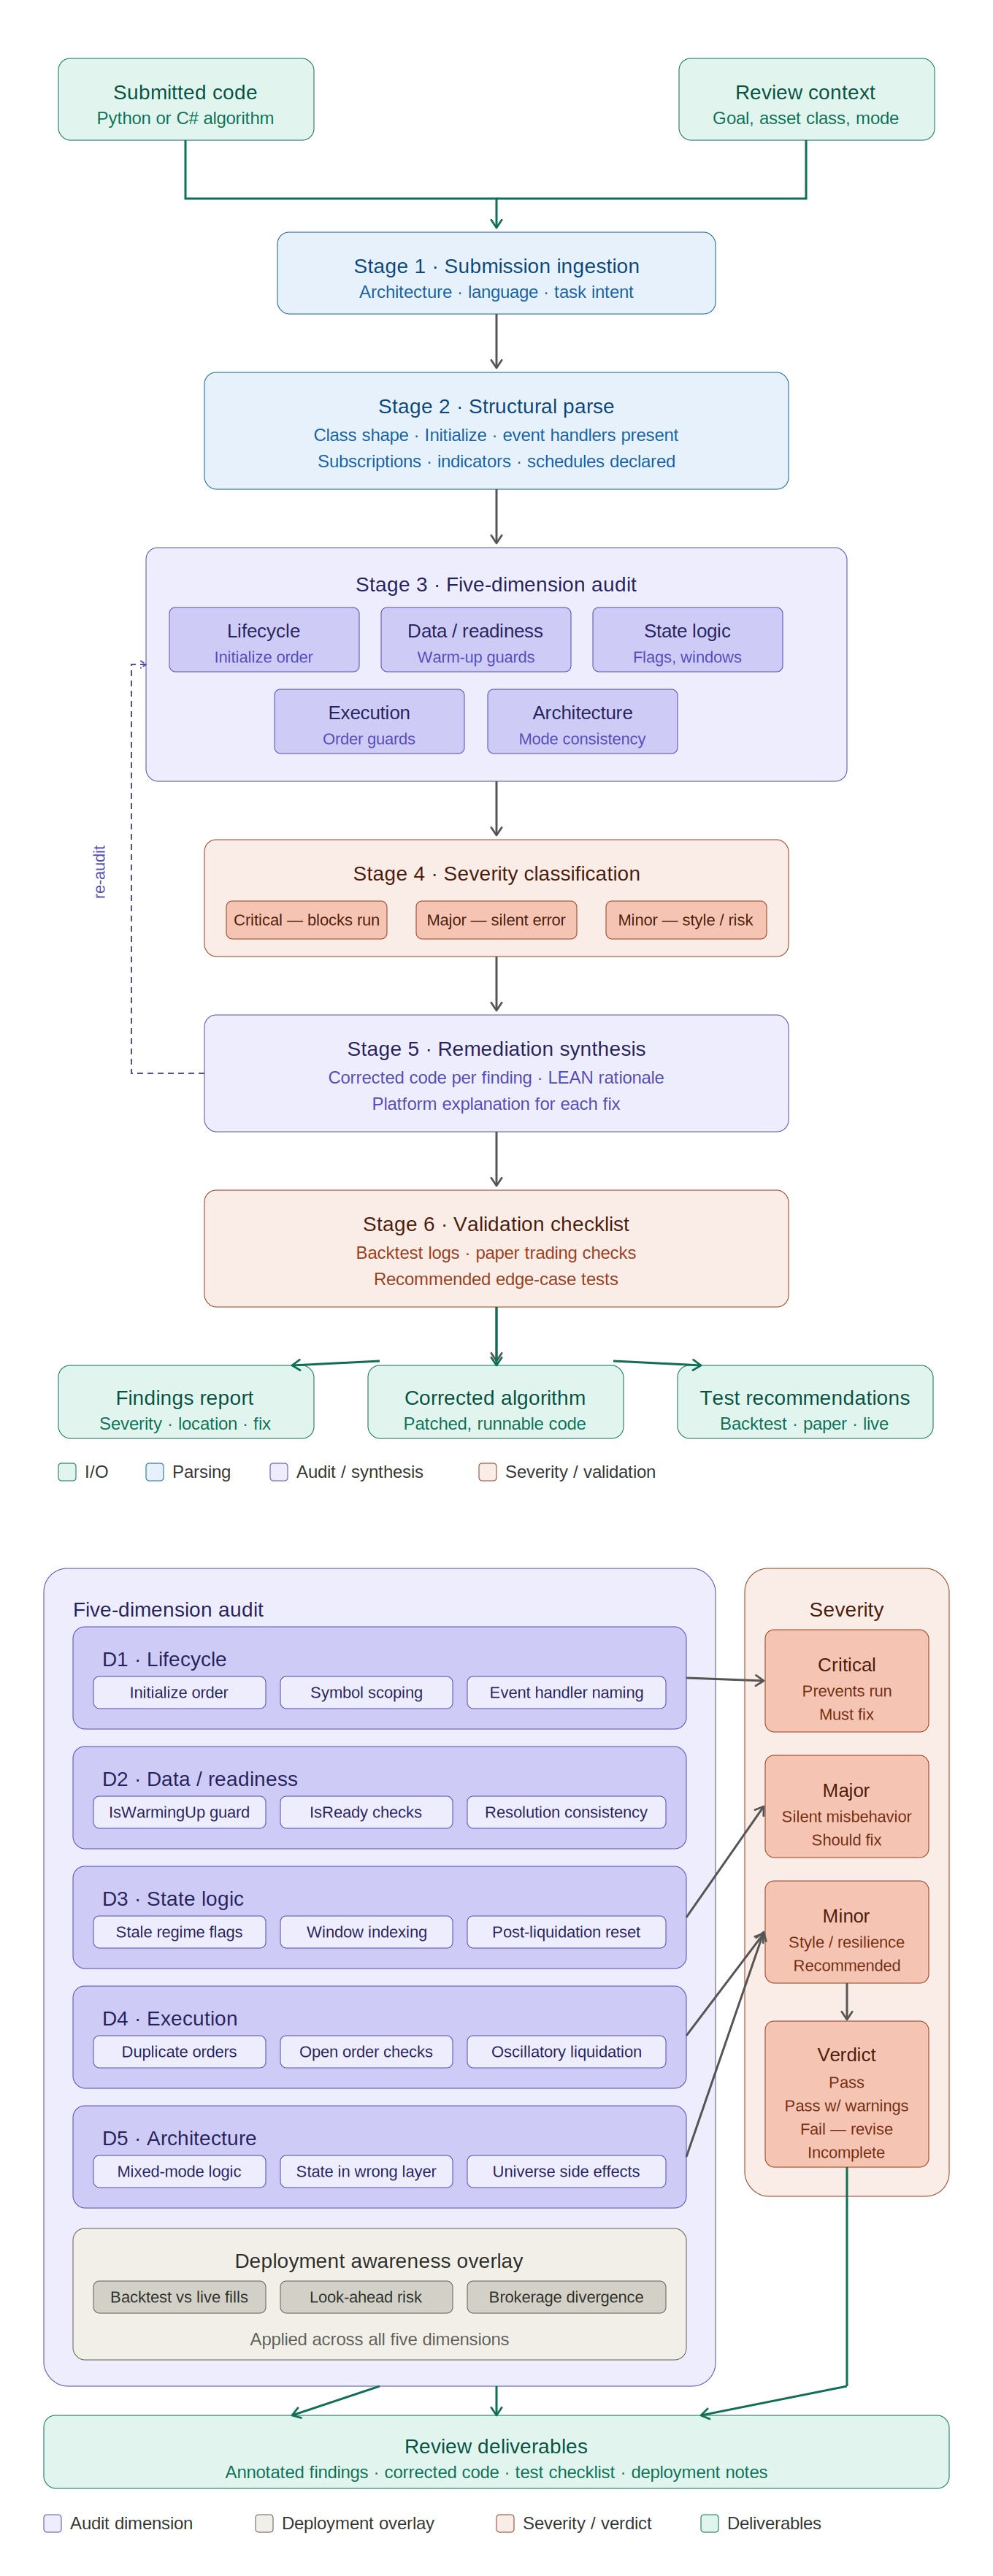

##2.CODE AND IMPLEMENTATION

In [2]:
# ============================================================
#  QuantConnect Code Reviewer Agent
#  Paste this into a Google Colab notebook and run each cell.
# ============================================================

# ── CELL 1: Install dependencies ──────────────────────────
!pip install anthropic -q


# ── CELL 2: Imports & API key ─────────────────────────────
import anthropic
from google.colab import userdata

client = anthropic.Anthropic(api_key=userdata.get("ANTHROPIC_API_KEY"))
MODEL  = "claude-haiku-4-5-20251001"


# ── CELL 3: Core stage runner ─────────────────────────────

def run_stage(stage_name: str, system_prompt: str, user_message: str) -> str:
    """Send one stage request to Claude and return the text response."""
    print(f"\n{'='*60}")
    print(f"  STAGE: {stage_name}")
    print(f"{'='*60}")
    response = client.messages.create(
        model=MODEL,
        max_tokens=2048,
        system=system_prompt,
        messages=[{"role": "user", "content": user_message}]
    )
    result = response.content[0].text
    print(result)
    return result


# ── CELL 4: Stage functions ───────────────────────────────

# ── Stage 1: Submission Ingestion ─────────────────────────
def stage1_ingest(code: str, context: str = "") -> str:
    system = """You are Stage 1 of a QuantConnect Code Reviewer Agent.
Your job is SUBMISSION INGESTION.
Classify the submitted algorithm along three dimensions and output them clearly:

  ARCHITECTURE   – monolithic QCAlgorithm OR Algorithm Framework OR mixed/unclear
  LANGUAGE       – Python OR C#
  TASK INTENT    – what the strategy appears to be trying to do (1–2 sentences)

Then list all top-level structural elements you can see:
  ELEMENTS PRESENT – class name, Initialize, OnData, Schedule.On, OnSecuritiesChanged,
                     OnOrderEvent, subscriptions, indicators, custom methods, etc.
  ELEMENTS MISSING – any lifecycle elements that appear absent

Keep it structured and concise. No verdict yet."""

    user = f"""Submitted algorithm:\n\n```\n{code}\n```"""
    if context:
        user += f"\n\nAdditional context from user:\n{context}"
    return run_stage("1 · Submission ingestion", system, user)


# ── Stage 2: Structural Parse ─────────────────────────────
def stage2_parse(code: str, ingestion: str) -> str:
    system = """You are Stage 2 of a QuantConnect Code Reviewer Agent.
Your job is STRUCTURAL PARSE.
Given the ingestion summary and the original code, check the following
and report findings under each heading:

  INITIALIZE STRUCTURE
  - Is SetStartDate / SetEndDate / SetCash present?
  - Are all subscriptions declared before use?
  - Are indicators registered in Initialize?
  - Is SetWarmUp declared?
  - Are scheduled events set up correctly?

  EVENT HANDLER STRUCTURE
  - Are handler method signatures correct for the LEAN version?
  - Is OnData receiving the correct Slice parameter?
  - Are any expected handlers entirely absent?

  SUBSCRIPTION INTEGRITY
  - Are all symbols referenced elsewhere actually subscribed?
  - Are consolidators or custom data feeds declared properly?

Flag each item as OK, WARNING, or MISSING. No code fixes yet — just the parse report."""

    user = f"""INGESTION SUMMARY:\n{ingestion}\n\nORIGINAL CODE:\n```\n{code}\n```"""
    return run_stage("2 · Structural parse", system, user)


# ── Stage 3: Five-Dimension Audit ─────────────────────────
def stage3_audit(code: str, parse: str) -> str:
    system = """You are Stage 3 of a QuantConnect Code Reviewer Agent.
Your job is the FIVE-DIMENSION AUDIT.
For each dimension, list every finding with its location (method name or line description).

  D1 · LIFECYCLE
  - Initialize execution order (symbols before indicators, indicators before schedules)
  - Symbol reference safety (stored correctly, reused safely)
  - Event handler naming and method signature correctness

  D2 · DATA / READINESS
  - IsWarmingUp guard present and correctly placed
  - Indicator .IsReady checks before reading values
  - Resolution consistency between subscription and indicator registration
  - Missing data / sparse slice handling

  D3 · STATE LOGIC
  - Stale regime or signal flags that are never reset
  - RollingWindow indexing errors (off-by-one, accessing before filled)
  - State variables that are not reset after liquidation
  - Cross-bar state assumptions that may break on gaps

  D4 · EXECUTION
  - Repeated market order submissions without invested/pending check
  - Missing open order inspection before new order
  - Oscillatory liquidation risk (immediate re-entry after exit)
  - Target-based vs ticket-based execution confusion

  D5 · ARCHITECTURE
  - Monolithic logic leaking into Algorithm Framework models
  - State held in the wrong component (e.g. alpha model carrying portfolio state)
  - Universe selection side effects outside OnSecuritiesChanged
  - Indicator management scattered across multiple components

For each finding write:
  [D#] [LOCATION] – description of the problem

If a dimension is fully clean, write: [D#] No issues found."""

    user = f"""PARSE REPORT:\n{parse}\n\nORIGINAL CODE:\n```\n{code}\n```"""
    return run_stage("3 · Five-dimension audit", system, user)


# ── Stage 4: Severity Classification ──────────────────────
def stage4_severity(audit: str) -> str:
    system = """You are Stage 4 of a QuantConnect Code Reviewer Agent.
Your job is SEVERITY CLASSIFICATION.
Take the raw audit findings and assign each one a severity level.

Severity definitions:
  CRITICAL  – prevents the algorithm from running or causes immediate runtime exception
  MAJOR     – algorithm runs but produces silently incorrect behavior
              (wrong signals, missed trades, inflated backtest returns, look-ahead bias)
  MINOR     – works correctly but is fragile, hard to maintain, or violates platform idioms

Output a structured table:

  SEVERITY | DIMENSION | LOCATION | DESCRIPTION

Then provide a VERDICT:
  PASS           – no critical or major findings
  PASS W/ WARNINGS – no critical findings, at least one major finding
  FAIL — REVISE  – at least one critical finding
  INCOMPLETE     – insufficient code to assess (missing key sections)

State the verdict clearly on its own line."""

    user = f"""AUDIT FINDINGS:\n{audit}"""
    return run_stage("4 · Severity classification", system, user)


# ── Stage 5: Remediation Synthesis ────────────────────────
def stage5_remediate(code: str, audit: str, severity: str) -> str:
    system = """You are Stage 5 of a QuantConnect Code Reviewer Agent.
Your job is REMEDIATION SYNTHESIS.

For every CRITICAL and MAJOR finding, produce:
  1. The specific corrected code snippet (not the whole file — just the relevant block)
  2. A one-sentence LEAN platform rationale explaining WHY the original was wrong
     and why the fix is correct

For MINOR findings, list them as brief improvement notes without full code rewrites
unless the fix is trivial (one line).

Format each fix as:

  FIX [#]: [Severity] — [Dimension] — [Location]
  PROBLEM:  <one sentence>
  RATIONALE: <one sentence explaining the LEAN-specific reason>
  CORRECTED CODE:
  ```python
  <fixed snippet>
  ```

After all individual fixes, output the FULL CORRECTED ALGORITHM incorporating
every fix — a complete, copy-paste-ready Python file."""

    user = f"""SEVERITY REPORT:\n{severity}\n\nAUDIT FINDINGS:\n{audit}\n\nORIGINAL CODE:\n```\n{code}\n```"""
    return run_stage("5 · Remediation synthesis", system, user)


# ── Stage 6: Validation Checklist ─────────────────────────
def stage6_validate(code: str, severity: str, remediation: str) -> str:
    system = """You are Stage 6 of a QuantConnect Code Reviewer Agent.
Your job is the VALIDATION CHECKLIST.
Given the severity findings and the remediated code, produce a practical
test plan the user should run to confirm the fixes are working.

Structure your output as:

  BACKTEST CHECKS
  - Specific things to look for in the backtest log and equity curve
  - Any periods or market regimes that stress-test the strategy's known weak points

  PAPER TRADING CHECKS
  - Behaviors to monitor in a live paper trade session
  - Order flow, position transitions, and universe changes to watch

  EDGE CASE TESTS
  - Specific scenarios to test manually (e.g. gap openings, halted securities,
    missing data bars, universe membership changes mid-session)

  DEPLOYMENT WARNINGS
  - Any remaining differences between backtest and live behavior to flag
  - Brokerage-specific or data-latency considerations

Keep the checklist actionable and specific to the findings from this review."""

    user = f"""SEVERITY REPORT:\n{severity}\n\nREMEDIATION SUMMARY:\n{remediation[:800]}\n\nFINAL CODE (excerpt):\n```\n{code[:600]}\n```"""
    return run_stage("6 · Validation checklist", system, user)


# ── CELL 5: Define the algorithm to review ────────────────

# ── Paste your QuantConnect algorithm here ────────────────
ALGORITHM_TO_REVIEW = """
from AlgorithmImports import *

class MomentumStrategy(QCAlgorithm):
    def Initialize(self):
        self.SetStartDate(2022, 1, 1)
        self.SetEndDate(2023, 12, 31)
        self.SetCash(100000)

        self.symbol = self.AddEquity("SPY", Resolution.Daily).Symbol

        self.fast = self.SMA(self.symbol, 20, Resolution.Daily)
        self.slow = self.SMA(self.symbol, 50, Resolution.Daily)

    def OnData(self, data):
        if not self.fast.IsReady:
            return

        if self.fast.Current.Value > self.slow.Current.Value:
            self.SetHoldings(self.symbol, 1.0)
        else:
            self.Liquidate(self.symbol)
"""

# ── Optional: add context about the strategy intent ───────
REVIEW_CONTEXT = "Daily momentum strategy on SPY using SMA crossover. Targeting QuantConnect cloud backtest."


# ── CELL 6: Run the full review pipeline ──────────────────

print("\n" + "█"*60)
print("  QuantConnect Code Reviewer Agent  –  Starting pipeline")
print("█"*60)

# Stage 1
ingestion   = stage1_ingest(ALGORITHM_TO_REVIEW, REVIEW_CONTEXT)

# Stage 2
parse       = stage2_parse(ALGORITHM_TO_REVIEW, ingestion)

# Stage 3
audit       = stage3_audit(ALGORITHM_TO_REVIEW, parse)

# Stage 4
severity    = stage4_severity(audit)

# Stage 5
remediation = stage5_remediate(ALGORITHM_TO_REVIEW, audit, severity)

# Stage 6
validation  = stage6_validate(ALGORITHM_TO_REVIEW, severity, remediation)

print("\n" + "█"*60)
print("  PIPELINE COMPLETE")
print("█"*60)


# ── CELL 7: Print the final deliverables ──────────────────

DIVIDER = "=" * 60

print(f"\n{DIVIDER}\n  SEVERITY VERDICT\n{DIVIDER}")
# Extract just the verdict line from the severity report
for line in severity.splitlines():
    if any(word in line.upper() for word in ["PASS", "FAIL", "INCOMPLETE", "VERDICT"]):
        print(line)

print(f"\n{DIVIDER}\n  CORRECTED ALGORITHM\n{DIVIDER}")
# The remediation stage embeds the full corrected file — print it all
print(remediation)

print(f"\n{DIVIDER}\n  VALIDATION CHECKLIST\n{DIVIDER}")
print(validation)


████████████████████████████████████████████████████████████
  QuantConnect Code Reviewer Agent  –  Starting pipeline
████████████████████████████████████████████████████████████

  STAGE: 1 · Submission ingestion
# SUBMISSION INGESTION REPORT

## CLASSIFICATION

| Dimension | Classification |
|-----------|---|
| **ARCHITECTURE** | Monolithic QCAlgorithm |
| **LANGUAGE** | Python |
| **TASK INTENT** | A daily-rebalanced momentum strategy that goes long SPY when the 20-day SMA crosses above the 50-day SMA, and liquidates when it crosses below. |

---

## STRUCTURAL ANALYSIS

### ELEMENTS PRESENT
- ✓ `MomentumStrategy` class (inherits QCAlgorithm)
- ✓ `Initialize()` – date range, cash, equity subscription, two SMA indicators
- ✓ `OnData()` – crossover logic with readiness check
- ✓ Subscriptions – SPY at Daily resolution
- ✓ Indicators – `self.fast` (SMA 20), `self.slow` (SMA 50)
- ✓ Order execution – `SetHoldings()`, `Liquidate()`

### ELEMENTS MISSING
- ✗ `OnOrderEvent()` – no order f

##3.CONCLUSIONS

**Conclusion — Limitations, Extensions, and the Logic of Staged Review**

*What the reviewer agent does well, where it falls short, and how it could be made more powerful*

---

**What the Agent Gets Right**

The QuantConnect Code Reviewer Agent is built around a single insight that most ad-hoc code review misses: the hardest bugs in an algorithmic trading system are not the ones that cause errors. They are the ones that cause silence. A strategy that submits a duplicate market order on every bar will not throw an exception. A strategy that reads an indicator value before warm-up is complete will not crash. A strategy that never resets its regime flag after liquidation will continue running, generating signals, placing trades, and producing backtest results — all of which are quietly wrong. These failures are invisible to a syntax checker, invisible to the LEAN compiler, and invisible to a casual reader who is focused on the logical structure of the code rather than its runtime behavior under edge conditions.

The staged pipeline addresses this by separating the act of reading code from the act of understanding it. Stage 1 reads. Stage 2 inspects structure. Stage 3 interprets behavior across five independent dimensions. Stage 4 classifies consequences. Stage 5 fixes. Stage 6 tests. At no point is the agent asked to do all of these things simultaneously, which means each stage can be thorough rather than superficial. This is the core contribution of the design, and it is what separates a multi-stage review pipeline from a single-prompt code critique.

---

**Limitation One — No Execution Environment**

The most significant limitation of the current agent is that it never runs the code. Every finding, every fix, every severity classification is based on static analysis — reading the source and reasoning about what it would do at runtime. This is necessarily incomplete. Some bugs only manifest under specific data conditions: a security that goes through a corporate action mid-backtest, a day with no trading volume that produces an empty slice, a universe membership change that arrives at the same time as a scheduled rebalance. Static analysis cannot detect these bugs because they are conditional on data, not on code structure.

The natural extension here is to integrate a LEAN execution environment into the pipeline. After Stage 5 generates the corrected algorithm, a Stage 5b could submit it to the QuantConnect API or a local LEAN Docker container, run a short backtest over a deliberately stressful historical period, parse the resulting logs for warnings and errors, and feed those findings back as additional audit input. This would transform the pipeline from a static reviewer into a dynamic one — capable of catching not just what the code says but what it actually does when data flows through it.

---

**Limitation Two — Severity Is Linguistic, Not Empirical**

The severity classifications produced by Stage 4 are based on Claude's reasoning about likely runtime consequences, not on measured outcomes. When Stage 4 classifies a missing `IsWarmingUp` guard as Major rather than Critical, it is making a judgment about how often and how severely the bug is likely to manifest, based on its understanding of the LEAN warm-up mechanism. That judgment is usually correct, but it is not infallible. A sophisticated strategy where indicators are read in a scheduled event that fires before warm-up has elapsed might produce a Critical failure from what appears to be a Minor omission. Conversely, a bug that looks Critical from the code structure might be harmless in practice because a downstream condition always catches it.

Improving severity accuracy requires empirical grounding. A richer version of the pipeline would maintain a database of known bug patterns drawn from real QuantConnect community reports, backtested failure cases, and platform documentation errata. Stage 4 would retrieve the closest matching patterns before classifying each finding, anchoring its severity judgments in documented evidence rather than pure reasoning. This is a retrieval-augmented approach to static analysis, and it would substantially improve the reliability of the verdict.

---

**Limitation Three — Single-File Scope**

The current pipeline reviews a single algorithm file. Real QuantConnect projects, particularly those using the Algorithm Framework, often span multiple files: separate modules for custom universe selection models, alpha models, portfolio construction models, and risk management models. A bug in an alpha model that produces duplicate insights, or a portfolio construction model that silently ignores zero-weight targets, will not be caught by reviewing the main algorithm file alone because the problematic code lives elsewhere.

Extending the agent to multi-file projects requires a preliminary stage that maps the dependency graph across files, identifies which components are custom versus built-in, and routes each component to the appropriate audit dimension. This is a harder problem than single-file review because the bugs that span module boundaries — state shared across components in ways that violate the Algorithm Framework's intended isolation — are precisely the ones that are most difficult to detect and most damaging when they reach production.

---

**Limitation Four — No Memory Across Sessions**

Every time the notebook is run, the agent starts from scratch. If a user submits an algorithm, receives a set of findings, applies some fixes, and resubmits, the agent treats the second submission as an entirely new review with no awareness of the previous session. This means it may re-flag issues that were intentionally left in place, miss regressions introduced by the fixes, and fail to recognize that the user has already addressed certain findings.

A session-aware reviewer would maintain a structured record of prior findings and their disposition — fixed, acknowledged, deferred, or disputed — and compare each new submission against this history. Regressions would be flagged with explicit reference to the prior clean state. Repeated findings that the user has acknowledged but not fixed would be presented differently from new findings. This kind of continuity would make the reviewer genuinely useful across the development lifecycle of a strategy, not just as a one-time gate before deployment.

---

**The Broader Point**

All four limitations share a common structure: the agent operates on text, in isolation, without memory, and without feedback from execution. Each of those constraints is a design choice driven by simplicity, not a fundamental ceiling on what the approach can achieve. Removing them one by one — adding execution feedback, empirical severity grounding, multi-file scope, and session memory — would produce progressively more capable versions of the same pipeline without changing its fundamental architecture. The staged review structure is not a workaround for the limitations of language models; it is a principled decomposition of a genuinely hard problem. The limitations are engineering gaps, not conceptual ones, and each of them has a clear path to resolution.